# Visual Speech Recognition — Training

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
import pickle
import numpy as np
import copy
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

from torch.optim.lr_scheduler import LinearLR, SequentialLR, CosineAnnealingLR

from model import LipReadingTransformer

## Гиперпараметры и конфигурация

In [ ]:
from model import load_config

# ── Пути и сплиты ──
DATA_PATH = "D:/Datasets/Dataset_720_proc"
MODEL_CONFIG_PATH = "configs/model_config_v4.json"

TRAIN_CLIPS = [f"pt{i}" for i in range(1, 12)]   # pt1 – pt11
VAL_CLIPS   = [f"pt{i}" for i in range(12, 14)]   # pt12 – pt13
TEST_CLIPS  = [f"pt{i}" for i in range(14, 16)]   # pt14 – pt15

# ── Загрузка конфига модели ──
MODEL_CONFIG = load_config(MODEL_CONFIG_PATH)

VOCAB_SIZE = MODEL_CONFIG["vocab_size"]
MAX_FRAMES = MODEL_CONFIG["max_frames"]
MAX_TOKENS = MODEL_CONFIG["max_tokens"]

# ── Скользящее окно ──
FRAME_STRIDE = 10
TOKEN_CONTENT_LEN = MAX_TOKENS - 1  # 11 контентных токенов (+ BOS/EOS)
TOKEN_STRIDE = 3

# ── Специальные токены (GPT-2 vocab = 50257) ──
EOS_TOKEN_ID = 50256   # <|endoftext|> — уже есть в GPT-2
PAD_TOKEN_ID = 50257   # новый
BOS_TOKEN_ID = 50258   # новый
# VOCAB_SIZE должен быть 50259 и задан в model_config.json

# ── Обучение ──
BATCH_SIZE    = 12
NUM_EPOCHS    = 300
WARMUP_EPOCHS = 50
LEARNING_RATE = 3e-4
WEIGHT_DECAY  = 1e-5

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
print(f"Config: d_model={MODEL_CONFIG['d_model']}, nhead={MODEL_CONFIG['nhead']}, "
      f"num_layers={MODEL_CONFIG['num_layers']}, dropout={MODEL_CONFIG['dropout']}")

Device: cuda
Config: d_model=64, nhead=8, num_layers=4, dropout=0.4



A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.4 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\Maksim\AppData\Roaming\Python\Python311\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "C:\Users\Maksim\AppData\Roaming\Python\Python311\site-packages\traitlets\config\application.py", line 1046, in launch_instance
    app.start()
  File "C:\Users\Maksim\AppData\Roaming\Python\Python311\site-packages\ipykernel\kernelapp.py", line 736, in start
    self.io

## Dataset со скользящим окном

In [3]:
class LipReadingDataset(Dataset):
    """
    Загружает .pkl-файлы из указанных клипов.
    Если кадров > MAX_FRAMES, нарезает скользящим окном:
        кадры:  окно 40, сдвиг 10
        токены: окно 11, сдвиг 3
    Каждый сэмпл возвращает фиксированные тензоры для батчинга.
    """

    def __init__(self, data_path, clip_names,
                 max_frames=MAX_FRAMES, frame_stride=FRAME_STRIDE,
                 max_tokens=MAX_TOKENS, token_stride=TOKEN_STRIDE):
        self.max_frames = max_frames
        self.max_tokens = max_tokens
        self.token_content_len = max_tokens - 1  # место под BOS/EOS

        data_path = Path(data_path)
        # Индекс: (pkl_path, frame_start, token_start, actual_frames)
        self.samples = []

        for clip_name in sorted(clip_names):
            clip_dir = data_path / clip_name
            if not clip_dir.exists():
                print(f"[!] Папка {clip_dir} не найдена, пропуск")
                continue

            pkl_files = sorted(
                clip_dir.glob("*.pkl"),
                key=lambda f: int(f.stem.split("_")[-1])
            )

            for pkl_file in pkl_files:
                with open(pkl_file, "rb") as f:
                    data = pickle.load(f)

                num_frames = data["num_frames"]
                num_tokens = len(data["input_ids"])

                if num_frames <= max_frames:
                    # Один сэмпл, без скольжения
                    self.samples.append((str(pkl_file), 0, 0, num_frames))
                else:
                    # Скользящее окно
                    f_start, t_start = 0, 0
                    while f_start + max_frames <= num_frames:
                        t_end = min(t_start + self.token_content_len, num_tokens)
                        if t_end > t_start:
                            self.samples.append((str(pkl_file), f_start, t_start, max_frames))
                        f_start += frame_stride
                        t_start += token_stride

        print(f"Загружено {len(self.samples)} сэмплов из {len(clip_names)} клипов")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        pkl_path, f_start, t_start, actual_frames = self.samples[idx]

        with open(pkl_path, "rb") as f:
            data = pickle.load(f)

        frames = data["frames"]       # list of np.ndarray (H, W, C), uint8
        ids    = data["input_ids"]     # list of int

        # ── Кадры ──
        chunk = frames[f_start : f_start + self.max_frames]
        chunk = np.stack(chunk)                                    # (T, H, W, C)
        chunk = np.transpose(chunk, (0, 3, 1, 2)).astype(np.float32) / 255.0  # (T, C, H, W)

        n_real_frames = chunk.shape[0]
        if n_real_frames < self.max_frames:
            pad = np.zeros(
                (self.max_frames - n_real_frames, *chunk.shape[1:]),
                dtype=np.float32,
            )
            chunk = np.concatenate([chunk, pad], axis=0)

        # Маска паддинга для энкодера: True = игнорировать
        src_padding_mask = [False] * n_real_frames + [True] * (self.max_frames - n_real_frames)

        # ── Токены ──
        content = ids[t_start : t_start + self.token_content_len]

        # decoder_input: [BOS, t1, …, tK, PAD…]  длина MAX_TOKENS
        decoder_input = [BOS_TOKEN_ID] + content
        # target:        [t1, …, tK, EOS, PAD…]   длина MAX_TOKENS
        target = content + [EOS_TOKEN_ID]

        dec_len = len(decoder_input)
        decoder_input += [PAD_TOKEN_ID] * (self.max_tokens - dec_len)
        target        += [PAD_TOKEN_ID] * (self.max_tokens - len(target))

        # True = позиция игнорируется (паддинг)
        tgt_padding_mask = [False] * dec_len + [True] * (self.max_tokens - dec_len)

        return {
            "frames":           torch.tensor(chunk, dtype=torch.float32),
            "src_padding_mask": torch.tensor(src_padding_mask, dtype=torch.bool),
            "decoder_input":    torch.tensor(decoder_input, dtype=torch.long),
            "target":           torch.tensor(target, dtype=torch.long),
            "tgt_padding_mask": torch.tensor(tgt_padding_mask, dtype=torch.bool),
        }

## Создание датасетов и загрузчиков

In [4]:
train_dataset = LipReadingDataset(DATA_PATH, TRAIN_CLIPS)
val_dataset   = LipReadingDataset(DATA_PATH, VAL_CLIPS)
test_dataset  = LipReadingDataset(DATA_PATH, TEST_CLIPS)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

# Проверка одного батча
batch = next(iter(train_loader))
print("frames:          ", batch["frames"].shape)           # [B, 40, 3, 96, 64]
print("src_padding_mask:", batch["src_padding_mask"].shape)  # [B, 40]
print("decoder_input:   ", batch["decoder_input"].shape)     # [B, 12]
print("target:          ", batch["target"].shape)            # [B, 12]
print("tgt_padding_mask:", batch["tgt_padding_mask"].shape)  # [B, 12]

[!] Папка D:\Datasets\Dataset_720_proc\pt10 не найдена, пропуск
Загружено 949 сэмплов из 11 клипов
Загружено 308 сэмплов из 2 клипов
Загружено 298 сэмплов из 2 клипов
frames:           torch.Size([12, 40, 3, 64, 96])
src_padding_mask: torch.Size([12, 40])
decoder_input:    torch.Size([12, 12])
target:           torch.Size([12, 12])
tgt_padding_mask: torch.Size([12, 12])


## Модель, оптимизатор, функция потерь

In [5]:
model = LipReadingTransformer(MODEL_CONFIG).to(DEVICE)

optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

# 1. Планировщик для разминки: растем с 0.1 * LR до LR за 5 эпох
warmup_scheduler = LinearLR(optimizer, start_factor=0.05, total_iters=WARMUP_EPOCHS)

# 2. Основной планировщик (уменьшаем T_max на количество эпох разминки)
main_scheduler = CosineAnnealingLR(optimizer, T_max=(NUM_EPOCHS - WARMUP_EPOCHS)//2, eta_min=1e-6)

# 3. Объединяем их
scheduler = SequentialLR(
    optimizer, 
    schedulers=[warmup_scheduler, main_scheduler], 
    milestones=[WARMUP_EPOCHS]
)

# scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS//2, eta_min=1e-6)
criterion = nn.CrossEntropyLoss(ignore_index=PAD_TOKEN_ID, label_smoothing=0.1)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Параметры: {total_params:,} всего, {trainable_params:,} обучаемых")

Параметры: 6,721,571 всего, 6,721,571 обучаемых


## Функции обучения и валидации

In [6]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total_tokens = 0

    for batch in loader:
        frames       = batch["frames"].to(device)            # [B, 40, 3, 96, 64]
        src_pad_mask = batch["src_padding_mask"].to(device)   # [B, 40]
        dec_input    = batch["decoder_input"].to(device)      # [B, 12]
        target       = batch["target"].to(device)             # [B, 12]
        tgt_pad_mask = batch["tgt_padding_mask"].to(device)   # [B, 12]

        logits = model(frames, dec_input,
                       tgt_padding_mask=tgt_pad_mask,
                       src_padding_mask=src_pad_mask)         # [B, 12, vocab_size]

        loss = criterion(logits.reshape(-1, VOCAB_SIZE), target.reshape(-1))

        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item() * frames.size(0)

        # Accuracy по не-PAD токенам
        preds = logits.argmax(dim=-1)
        mask = target != PAD_TOKEN_ID
        total_correct += (preds[mask] == target[mask]).sum().item()
        total_tokens  += mask.sum().item()

    avg_loss = total_loss / len(loader.dataset)
    accuracy = total_correct / total_tokens if total_tokens > 0 else 0.0
    return avg_loss, accuracy


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_tokens = 0

    for batch in loader:
        frames       = batch["frames"].to(device)
        src_pad_mask = batch["src_padding_mask"].to(device)
        dec_input    = batch["decoder_input"].to(device)
        target       = batch["target"].to(device)
        tgt_pad_mask = batch["tgt_padding_mask"].to(device)

        logits = model(frames, dec_input,
                       tgt_padding_mask=tgt_pad_mask,
                       src_padding_mask=src_pad_mask)

        loss = criterion(logits.reshape(-1, VOCAB_SIZE), target.reshape(-1))
        total_loss += loss.item() * frames.size(0)

        preds = logits.argmax(dim=-1)
        mask = target != PAD_TOKEN_ID
        total_correct += (preds[mask] == target[mask]).sum().item()
        total_tokens  += mask.sum().item()

    avg_loss = total_loss / len(loader.dataset)
    accuracy = total_correct / total_tokens if total_tokens > 0 else 0.0
    return avg_loss, accuracy

## Цикл обучения

In [7]:
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_val_loss = float("inf")
best_model_state = None

for epoch in tqdm(range(1, NUM_EPOCHS + 1), desc="Эпохи"):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
    val_loss, val_acc     = evaluate(model, val_loader, criterion, DEVICE)
    scheduler.step()

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    # Сохранение лучшей модели по val_loss
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = copy.deepcopy(model.state_dict())
        marker = " *"
    else:
        marker = ""

    if epoch % 1 == 0 or epoch == 1:
        lr = optimizer.param_groups[0]["lr"]
        print(
            f"Epoch {epoch:3d} | "
            f"train_loss={train_loss:.4f}  train_acc={train_acc:.3f} | "
            f"val_loss={val_loss:.4f}  val_acc={val_acc:.6f} | "
            f"lr={lr:.2e}{marker}"
        )

# Сохраняем лучшую модель
if best_model_state is not None:
    torch.save(best_model_state, "best_model.pt")
    print(f"\nЛучшая модель сохранена (val_loss={best_val_loss:.4f})")

Эпохи:   0%|          | 0/300 [00:00<?, ?it/s]

c:\Users\Maksim\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\nn\functional.py:4999: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(
c:\Users\Maksim\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\nn\modules\transformer.py:296: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. (Triggered internally at ..\aten\src\ATen\NestedTensorImpl.cpp:179.)
  output = torch._nested_tensor_from_mask(output, src_key_padding_mask.logical_not(), mask_check=False)
c:\Users\Maksim\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\nn\modules\activation.py:1160: UserWarning: Converting mask without torch.bool dtype to bool; this will negatively affect performance. Prefer to use a boolean mask directly. (Triggered internally at ..\aten\src\ATen\native\transformers\attention.cpp:152.)
  return torch._native_multi_head_attenti

Epoch   1 | train_loss=10.8253  train_acc=0.001 | val_loss=10.6468  val_acc=0.010 | lr=2.07e-05 *
Epoch   2 | train_loss=10.5854  train_acc=0.058 | val_loss=10.3502  val_acc=0.141 | lr=2.64e-05 *
Epoch   3 | train_loss=10.3281  train_acc=0.130 | val_loss=10.0808  val_acc=0.141 | lr=3.21e-05 *
Epoch   4 | train_loss=10.0583  train_acc=0.133 | val_loss=9.8133  val_acc=0.141 | lr=3.78e-05 *
Epoch   5 | train_loss=9.7647  train_acc=0.133 | val_loss=9.5288  val_acc=0.141 | lr=4.35e-05 *
Epoch   6 | train_loss=9.4200  train_acc=0.133 | val_loss=9.2242  val_acc=0.141 | lr=4.92e-05 *
Epoch   7 | train_loss=9.0610  train_acc=0.133 | val_loss=8.9031  val_acc=0.141 | lr=5.49e-05 *
Epoch   8 | train_loss=8.6720  train_acc=0.133 | val_loss=8.5767  val_acc=0.141 | lr=6.06e-05 *
Epoch   9 | train_loss=8.2677  train_acc=0.133 | val_loss=8.2642  val_acc=0.141 | lr=6.63e-05 *
Epoch  10 | train_loss=7.8856  train_acc=0.133 | val_loss=7.9922  val_acc=0.141 | lr=7.20e-05 *
Epoch  11 | train_loss=7.5238  tr

c:\Users\Maksim\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\optim\lr_scheduler.py:152: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


Epoch  50 | train_loss=6.2537  train_acc=0.152 | val_loss=7.4100  val_acc=0.154 | lr=3.00e-04 *
Epoch  51 | train_loss=6.2339  train_acc=0.151 | val_loss=7.4312  val_acc=0.146 | lr=3.00e-04
Epoch  52 | train_loss=6.2099  train_acc=0.153 | val_loss=7.4128  val_acc=0.153 | lr=3.00e-04
Epoch  53 | train_loss=6.1750  train_acc=0.151 | val_loss=7.4173  val_acc=0.141 | lr=3.00e-04
Epoch  54 | train_loss=6.1455  train_acc=0.152 | val_loss=7.4379  val_acc=0.138 | lr=2.99e-04
Epoch  55 | train_loss=6.1264  train_acc=0.152 | val_loss=7.4023  val_acc=0.148 | lr=2.99e-04 *
Epoch  56 | train_loss=6.0950  train_acc=0.152 | val_loss=7.4212  val_acc=0.139 | lr=2.98e-04
Epoch  57 | train_loss=6.0560  train_acc=0.150 | val_loss=7.3985  val_acc=0.145 | lr=2.98e-04 *
Epoch  58 | train_loss=6.0339  train_acc=0.155 | val_loss=7.3881  val_acc=0.155 | lr=2.97e-04 *
Epoch  59 | train_loss=5.9950  train_acc=0.155 | val_loss=7.4041  val_acc=0.150 | lr=2.96e-04
Epoch  60 | train_loss=5.9747  train_acc=0.153 | val

## Графики обучения

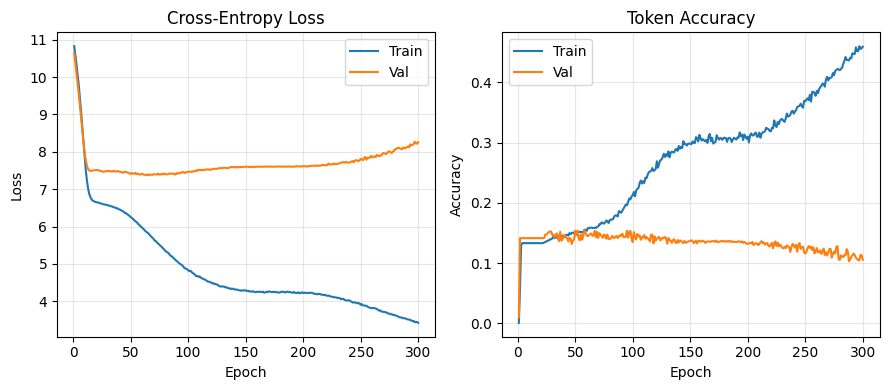

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
epochs_range = range(1, len(history["train_loss"]) + 1)

# Loss
axes[0].plot(epochs_range, history["train_loss"], label="Train")
axes[0].plot(epochs_range, history["val_loss"],   label="Val")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Cross-Entropy Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(epochs_range, history["train_acc"], label="Train")
axes[1].plot(epochs_range, history["val_acc"],   label="Val")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Token Accuracy")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"training_curves_D{MODEL_CONFIG['d_model']}_v4.png", dpi=150)
# plt.show()

## Оценка на тестовом наборе

In [9]:
# Загружаем лучшие веса
model.load_state_dict(torch.load("best_model.pt", map_location=DEVICE))

test_loss, test_acc = evaluate(model, test_loader, criterion, DEVICE)
print(f"Test loss: {test_loss:.4f}")
print(f"Test token accuracy: {test_acc:.3f}")

Test loss: 7.4121
Test token accuracy: 0.148


## Пример инференса (greedy decode)

In [10]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("gpt2")

@torch.no_grad()
def greedy_decode(model, video_frames, max_len=MAX_TOKENS, device=DEVICE):
    """Авторегрессионная генерация токенов по видео."""
    model.eval()
    video = video_frames.unsqueeze(0).to(device)  # [1, 40, 3, 96, 64]

    # Энкодер
    memory = model.encoder(video)
    if isinstance(memory, tuple):
        memory = memory[0]

    # Начинаем с BOS
    generated = [BOS_TOKEN_ID]

    for _ in range(max_len - 1):
        tgt = torch.tensor([generated], dtype=torch.long, device=device)
        logits = model.decoder(tgt, memory)            # [1, seq_len, vocab]
        next_token = logits[0, -1].argmax().item()
        generated.append(next_token)
        if next_token == EOS_TOKEN_ID:
            break

    # Убираем BOS и EOS
    tokens = [t for t in generated if t not in (BOS_TOKEN_ID, EOS_TOKEN_ID, PAD_TOKEN_ID)]
    return tokens


# Пример на первом тестовом сэмпле
sample = test_dataset[0]
pred_ids = greedy_decode(model, sample["frames"])
pred_text = tokenizer.decode(pred_ids)

# Ground truth (убираем EOS/PAD из target)
gt_ids = [t for t in sample["target"].tolist() if t not in (EOS_TOKEN_ID, PAD_TOKEN_ID)]
gt_text = tokenizer.decode(gt_ids)

print(f"Predicted: {pred_text}")
print(f"Ground truth: {gt_text}")

Predicted: the,
Ground truth: London. On tonight's program, undercover


c:\Users\Maksim\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\nn\modules\activation.py:1160: UserWarning: Converting mask without torch.bool dtype to bool; this will negatively affect performance. Prefer to use a boolean mask directly. (Triggered internally at ..\aten\src\ATen\native\transformers\attention.cpp:152.)
  return torch._native_multi_head_attention(
